# March Machine Learning Mania 2026

Predict NCAA tournament outcomes (men's + women's) using an ensemble of XGBoost, LightGBM, AdaBoost, and TabICL v2.

- **Metric**: Brier score (MSE for binary outcomes)
- **Target**: P(lower TeamID beats higher TeamID)
- **Submission**: Every possible within-gender matchup

## 1. Setup

In [4]:
import sys
sys.path.append("/kaggle/usr/lib/notebooks/aelhajj/utils_py")
sys.path.append("/kaggle/usr/lib/notebooks/aelhajj/theme_py")

In [6]:
%pip install catppuccin[matplotlib] --quiet

Note: you may need to restart the kernel to use updated packages.


In [7]:
%pip install tabicl --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.5/206.5 kB 7.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

from theme_py import apply
from utils_py import (
    load_data, compute_elo, compute_season_stats, compute_massey_features,
    build_seed_map, build_training_data, build_features_vectorized, parse_seed,
    train_or_load, brier_score, leave_one_season_out_cv, compute_sample_weights,
    generate_submission,
    plot_brier_by_season, plot_feature_importance,
    plot_prediction_distribution, plot_calibration_curve,
    plot_model_comparison,
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from tabicl import TabICLClassifier

warnings.filterwarnings("ignore")
C = apply("mocha")
RANDOM_STATE = 42
print("Setup complete.")

Setup complete.


## 2. Data Loading

In [44]:
sys

<module 'sys' (built-in)>

In [46]:
data = load_data(Path("/kaggle/input/competitions/march-machine-learning-mania-2026"))
for name, df in data.items():
    print(f"{name:25s} {str(df.shape):>15s}")

m_teams                          (381, 4)
w_teams                          (379, 2)
m_regular                     (196823, 8)
w_regular                     (140825, 8)
m_regular_detail             (122775, 34)
w_regular_detail              (85505, 34)
m_tourney                       (2585, 8)
w_tourney                       (1717, 8)
m_tourney_detail               (1449, 34)
w_tourney_detail                (961, 34)
m_seeds                         (2626, 3)
w_seeds                         (1744, 3)
m_massey                     (5761702, 5)
sample_sub                    (519144, 2)
sample_sub2                   (132133, 2)


In [47]:
data["m_regular_detail"].head(3)

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,...,LFGA3,LFTM,LFTA,LOR,LDR,LAst,LTO,LStl,LBlk,LPF
0,2003,10,1104,68,1328,62,N,0,27,58,...,10,16,22,10,22,8,18,9,2,20
1,2003,10,1272,70,1393,63,N,0,26,62,...,24,9,20,20,25,7,12,8,6,16
2,2003,11,1266,73,1437,61,N,0,24,58,...,26,14,23,31,22,9,12,2,5,23


In [48]:
# Submission structure
print("Stage 1:", data["sample_sub"].shape)
print(data["sample_sub"].head())
print()
print("Stage 2:", data["sample_sub2"].shape)
print(data["sample_sub2"].head())

Stage 1: (519144, 2)
               ID  Pred
0  2022_1101_1102   0.5
1  2022_1101_1103   0.5
2  2022_1101_1104   0.5
3  2022_1101_1105   0.5
4  2022_1101_1106   0.5

Stage 2: (132133, 2)
               ID  Pred
0  2026_1101_1102   0.5
1  2026_1101_1103   0.5
2  2026_1101_1104   0.5
3  2026_1101_1105   0.5
4  2026_1101_1106   0.5


## 3. EDA

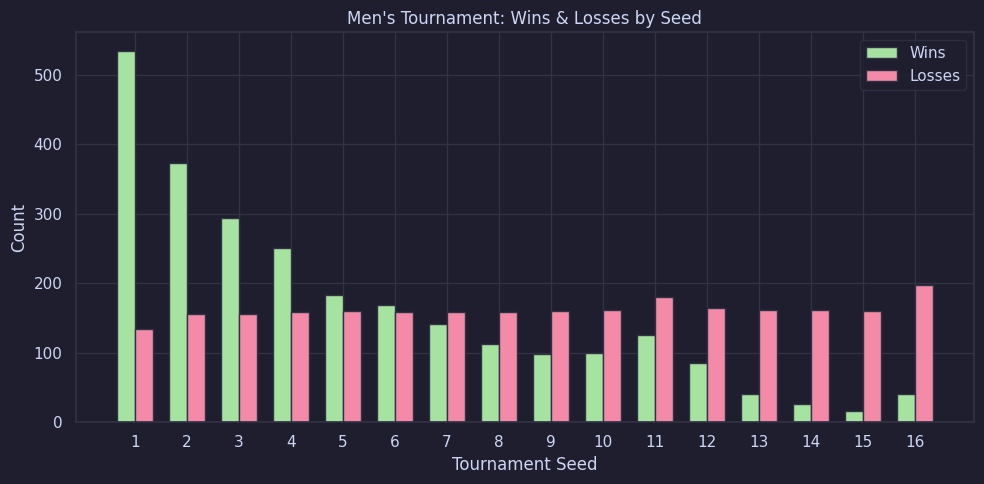

In [49]:
# Seed vs tournament wins (men's)
m_seeds = data["m_seeds"].copy()
m_seeds["SeedNum"] = m_seeds["Seed"].apply(parse_seed)
m_tourney = data["m_tourney"]

# Count wins by seed
w_seeds = m_tourney.merge(m_seeds, left_on=["Season", "WTeamID"], right_on=["Season", "TeamID"])
seed_wins = w_seeds.groupby("SeedNum").size().reindex(range(1, 17), fill_value=0)

l_seeds = m_tourney.merge(m_seeds, left_on=["Season", "LTeamID"], right_on=["Season", "TeamID"])
seed_losses = l_seeds.groupby("SeedNum").size().reindex(range(1, 17), fill_value=0)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(1, 17)
w = 0.35
ax.bar(x - w/2, seed_wins.values, w, label="Wins", color=C.green)
ax.bar(x + w/2, seed_losses.values, w, label="Losses", color=C.red)
ax.set_xlabel("Tournament Seed")
ax.set_ylabel("Count")
ax.set_title("Men's Tournament: Wins & Losses by Seed")
ax.set_xticks(x)
ax.legend()
plt.tight_layout()
plt.show()

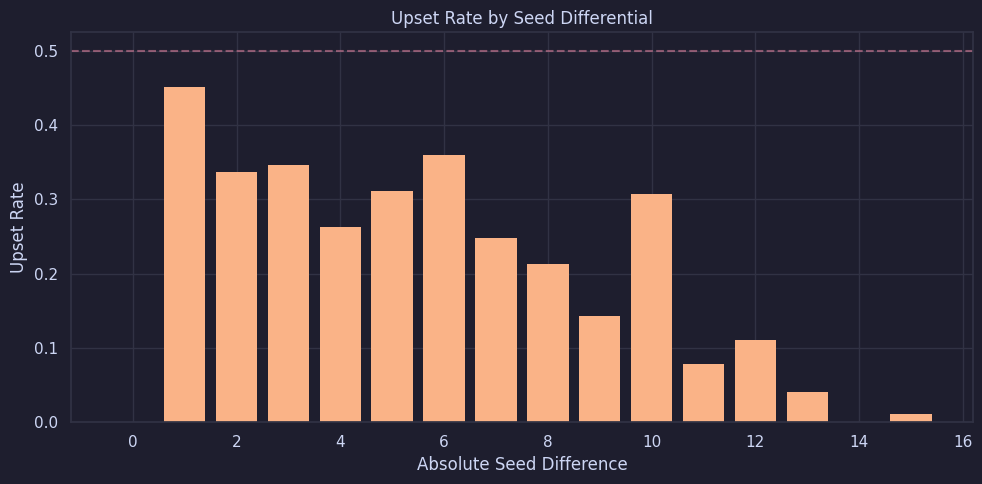

In [50]:
# Upset frequency: how often does the higher seed (worse number) win?
tourney_all = pd.concat([data["m_tourney"], data["w_tourney"]], ignore_index=True)
all_seeds = pd.concat([data["m_seeds"], data["w_seeds"]], ignore_index=True)
all_seeds["SeedNum"] = all_seeds["Seed"].apply(parse_seed)
seed_lookup = dict(zip(zip(all_seeds["Season"], all_seeds["TeamID"]), all_seeds["SeedNum"]))

upsets = []
for _, row in tourney_all.iterrows():
    ws = seed_lookup.get((row["Season"], row["WTeamID"]))
    ls = seed_lookup.get((row["Season"], row["LTeamID"]))
    if ws is not None and ls is not None:
        diff = abs(ws - ls)
        upset = ws > ls  # winner had a worse (higher) seed number
        upsets.append({"SeedDiff": diff, "Upset": int(upset)})

upset_df = pd.DataFrame(upsets)
upset_rate = upset_df.groupby("SeedDiff")["Upset"].mean()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(upset_rate.index, upset_rate.values, color=C.peach, edgecolor="none")
ax.axhline(0.5, color=C.red, linestyle="--", alpha=0.5)
ax.set_xlabel("Absolute Seed Difference")
ax.set_ylabel("Upset Rate")
ax.set_title("Upset Rate by Seed Differential")
plt.tight_layout()
plt.show()

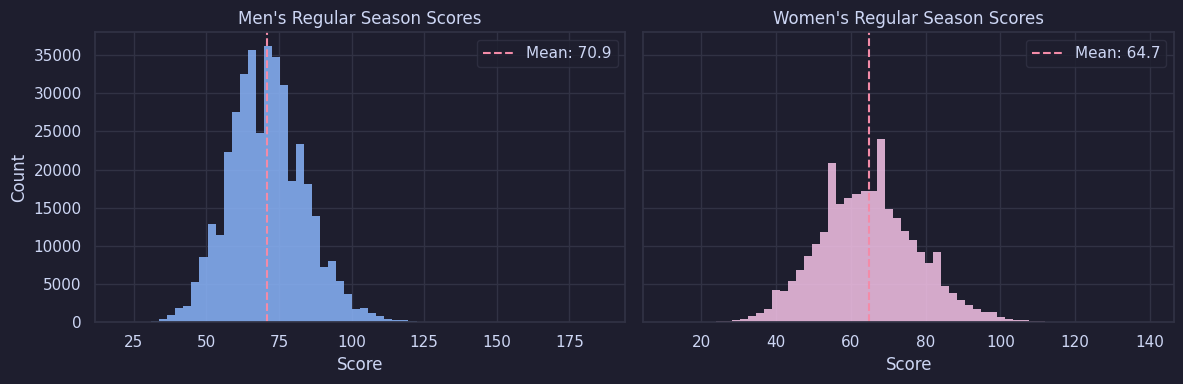

In [51]:
# Score distributions (men's vs women's regular season)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, (key, title, color) in zip(axes, [
    ("m_regular", "Men's", C.blue),
    ("w_regular", "Women's", C.pink),
]):
    df = data[key]
    scores = pd.concat([df["WScore"], df["LScore"]])
    ax.hist(scores, bins=60, color=color, edgecolor="none", alpha=0.85)
    ax.set_xlabel("Score")
    ax.set_title(f"{title} Regular Season Scores")
    ax.axvline(scores.mean(), color=C.red, linestyle="--", label=f"Mean: {scores.mean():.1f}")
    ax.legend()

axes[0].set_ylabel("Count")
plt.tight_layout()
plt.show()

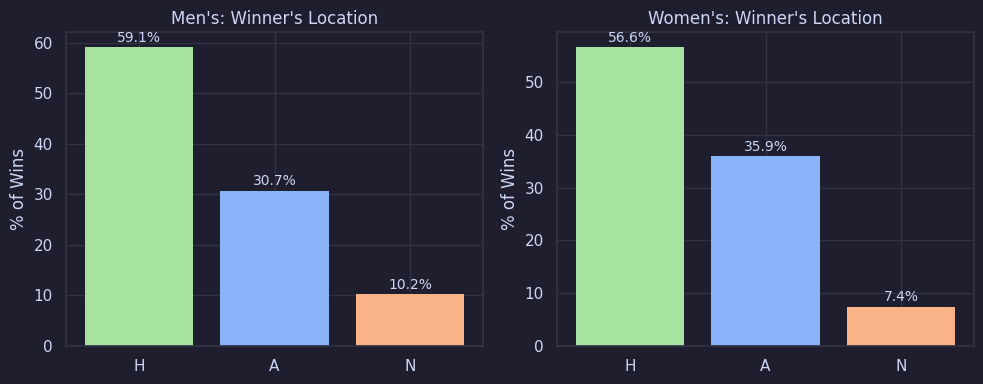

In [52]:
# Home court advantage
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (key, title) in zip(axes, [("m_regular", "Men's"), ("w_regular", "Women's")]):
    df = data[key]
    loc_counts = df["WLoc"].value_counts()
    total_games = len(df)
    pcts = (loc_counts / total_games * 100)
    bars = ax.bar(pcts.index, pcts.values, color=[C.green, C.blue, C.peach][:len(pcts)], edgecolor="none")
    ax.set_ylabel("% of Wins")
    ax.set_title(f"{title}: Winner's Location")
    for bar, pct in zip(bars, pcts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{pct:.1f}%", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

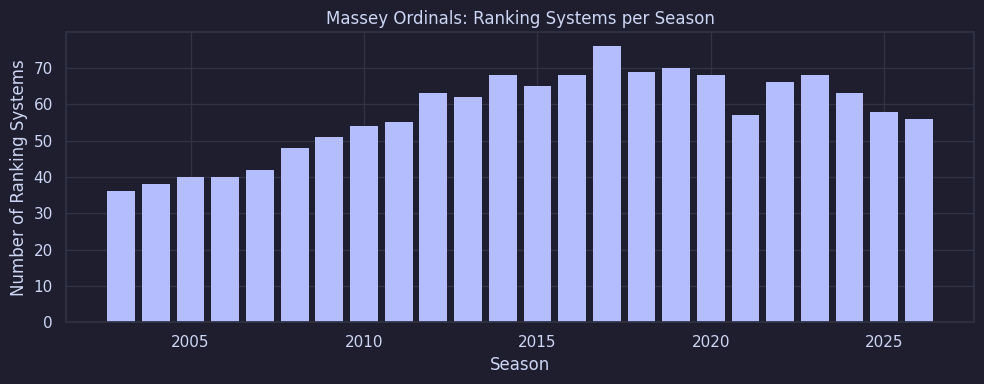

In [53]:
# Massey ordinals: systems per season
massey = data["m_massey"]
systems_per_season = massey.groupby("Season")["SystemName"].nunique()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(systems_per_season.index, systems_per_season.values, color=C.lavender, edgecolor="none")
ax.set_xlabel("Season")
ax.set_ylabel("Number of Ranking Systems")
ax.set_title("Massey Ordinals: Ranking Systems per Season")
plt.tight_layout()
plt.show()

## 4. Feature Engineering

In [54]:
# Elo: previous season (end-of-season, includes tournament) — long-term baseline
m_elo_prev = compute_elo(data["m_regular"], data["m_tourney"], include_tourney=True)
w_elo_prev = compute_elo(data["w_regular"], data["w_tourney"], include_tourney=True)
elo_prev = {**m_elo_prev, **w_elo_prev}
print(f"Previous-season Elo: {len(elo_prev):,} ratings")

Previous-season Elo: 24,158 ratings


In [55]:
# Elo: current season (regular season only, no tournament games) — current form
m_elo_curr = compute_elo(data["m_regular"], include_tourney=False)
w_elo_curr = compute_elo(data["w_regular"], include_tourney=False)
elo_curr = {**m_elo_curr, **w_elo_curr}
print(f"Current-season Elo: {len(elo_curr):,} ratings")

Current-season Elo: 24,158 ratings


In [56]:
# Seeds, season stats, Massey
seed_map  = build_seed_map(data["m_seeds"], data["w_seeds"])
print(f"Seed map: {len(seed_map):,} entries")

m_stats = compute_season_stats(data["m_regular_detail"])
w_stats = compute_season_stats(data["w_regular_detail"])
stats_df = pd.concat([m_stats, w_stats], ignore_index=True)
print(f"Season stats: {len(stats_df):,} team-seasons")

massey_df = compute_massey_features(data["m_massey"], day_threshold=128)
print(f"Massey features: {len(massey_df):,} team-seasons")

Seed map: 4,370 entries
Season stats: 14,311 team-seasons
Massey features: 7,980 team-seasons


In [57]:
# Sanity check: top men's teams by end-of-2025 Elo
m_teams_lut = dict(zip(data["m_teams"]["TeamID"], data["m_teams"]["TeamName"]))
top_m = sorted(
    [(m_teams_lut.get(tid, tid), r) for (s, tid), r in elo_prev.items()
     if s == 2025 and tid < 2000],
    key=lambda x: -x[1]
)[:10]
print("Top 10 men's teams by end-of-2025 Elo:")
for i, (name, elo) in enumerate(top_m, 1):
    print(f"  {i:2d}. {name}: {elo:.0f}")

Top 10 men's teams by end-of-2025 Elo:
   1. Houston: 1862
   2. Florida: 1820
   3. Duke: 1816
   4. Auburn: 1792
   5. Alabama: 1767
   6. Tennessee: 1765
   7. Drake: 1752
   8. Connecticut: 1744
   9. Michigan St: 1740
  10. St Mary's CA: 1738


## 5. Training Data

In [58]:
# Build training data from historical tournament results (2003+)
X, y, seasons = build_training_data(
    data["m_tourney"], data["w_tourney"],
    elo_prev, elo_curr, seed_map, stats_df, massey_df,
    min_season=2003,
)

FEATURE_COLS = list(X.columns)

print(f"Training set: {X.shape[0]:,} games, {X.shape[1]} features")
print(f"Seasons: {seasons.min()}–{seasons.max()}")
print(f"y balance (Team1 win rate): {y.mean():.3f}  ← should be ~0.5")
print("\nNaN counts (features with missing values):")
nan_counts = X.isna().sum()
print(nan_counts[nan_counts > 0])

Training set: 2,851 games, 20 features
Seasons: 2003–2025
y balance (Team1 win rate): 0.505  ← should be ~0.5

NaN counts (features with missing values):
WinPctDiff             441
AvgScoreMarginDiff     441
FGPctDiff              441
FG3PctDiff             441
FTPctDiff              441
AvgORDiff              441
AvgDRDiff              441
AvgAstDiff             441
AvgTODiff              441
AvgStlDiff             441
AvgBlkDiff             441
OppFGPctDiff           441
OppFG3PctDiff          441
MasseyMeanDiff        1402
MasseyMedianDiff      1402
dtype: int64


In [59]:
X.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
EloPrevDiff,2851.0,4.046,168.629,-579.517,-105.505,-0.553,118.741,614.535
EloCurrDiff,2851.0,2.590,131.147,-496.926,-76.983,-0.114,81.946,465.076
SeedT1,2851.0,6.776,4.682,1.000,3.000,6.000,11.000,16.000
SeedT2,2851.0,6.643,4.602,1.000,3.000,6.000,10.000,16.000
SeedDiff,2851.0,-0.133,7.415,-15.000,-5.000,0.000,5.000,15.000
WinPctDiff,2410.0,0.005,0.155,-0.633,-0.097,0.007,0.106,0.548
AvgScoreMarginDiff,2410.0,0.742,8.486,-33.073,-4.255,0.278,5.288,41.879
FGPctDiff,2410.0,0.005,0.039,-0.141,-0.021,0.005,0.028,0.155
FG3PctDiff,2410.0,0.003,0.040,-0.140,-0.024,0.003,0.028,0.155
FTPctDiff,2410.0,-0.000,0.053,-0.181,-0.037,0.000,0.037,0.183


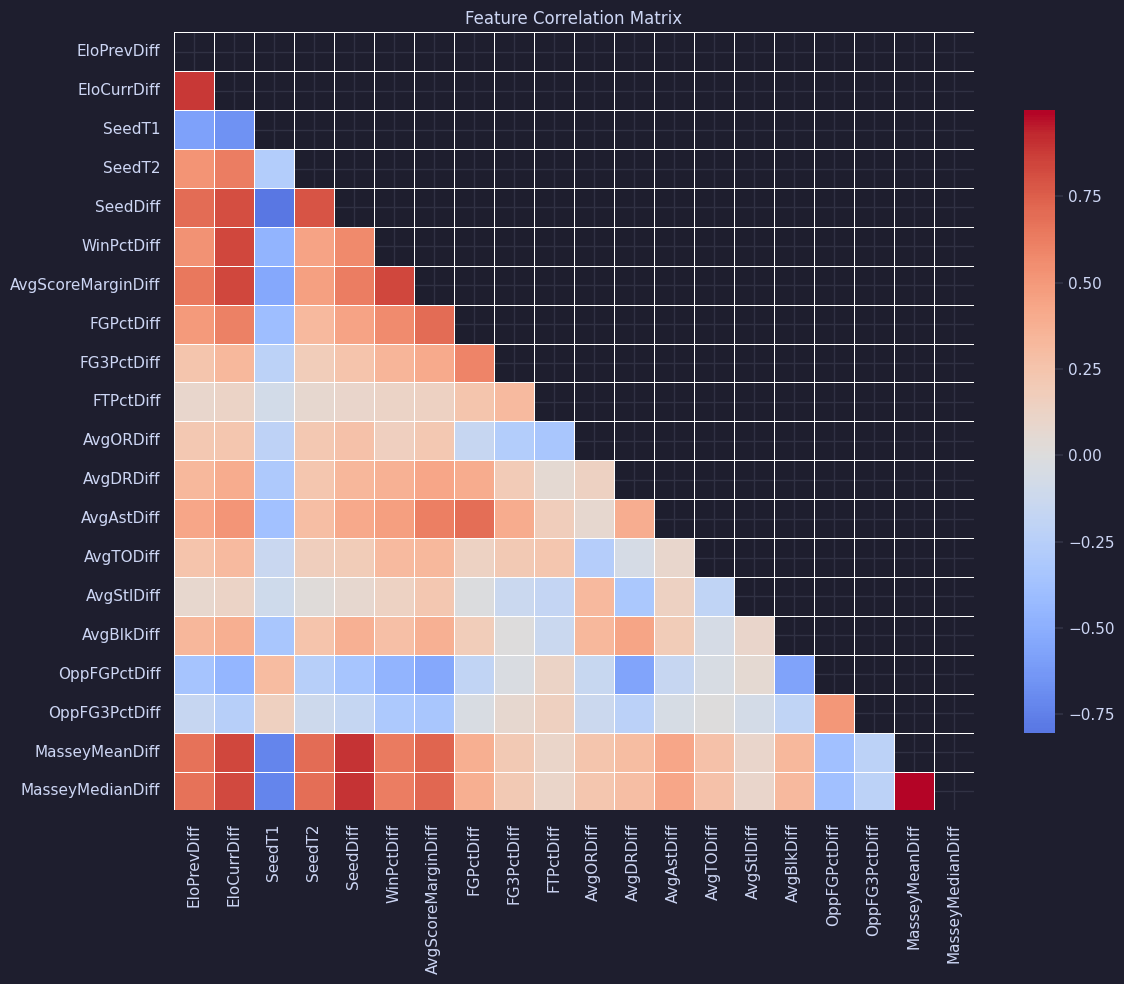

In [60]:
# Feature correlation heatmap
fig, ax = plt.subplots(figsize=(12, 10))
corr = X.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap="coolwarm", center=0,
            linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [61]:
# Compute training-set medians for NaN imputation (TabICL)
IMPUTE_MEDIANS = X.median().to_dict()

# Recency weights: decay=0.60 → 2025→1.0, 2024→0.6, 2023→0.36, 2021→0.13
SAMPLE_WEIGHTS = compute_sample_weights(seasons, decay=0.60)

# Explicit anomaly overrides (multiplied on top of decay weight)
_SEASON_OVERRIDES = {
    2021: 0.10,  # COVID bubble — all games in Indianapolis, no crowds, unreliable signal
}
for _s, _factor in _SEASON_OVERRIDES.items():
    SAMPLE_WEIGHTS[seasons.values == _s] *= _factor

print("Imputation medians ready.")
print(f"Sample weight range: [{SAMPLE_WEIGHTS.min():.5f}, {SAMPLE_WEIGHTS.max():.4f}]")
print("\nPer-season weights (non-zero only):")
_sw_by_season = {s: SAMPLE_WEIGHTS[seasons.values == s].mean() for s in sorted(seasons.unique())}
for s, w in _sw_by_season.items():
    bar = "█" * int(w * 30)
    note = " ← COVID bubble" if s == 2021 else ""
    print(f"  {s}: {w:.4f} {bar}{note}")

Imputation medians ready.
Sample weight range: [0.00001, 1.0000]

Per-season weights (non-zero only):
  2003: 0.0000 
  2004: 0.0000 
  2005: 0.0000 
  2006: 0.0001 
  2007: 0.0001 
  2008: 0.0002 
  2009: 0.0003 
  2010: 0.0005 
  2011: 0.0008 
  2012: 0.0013 
  2013: 0.0022 
  2014: 0.0036 
  2015: 0.0060 
  2016: 0.0101 
  2017: 0.0168 
  2018: 0.0280 
  2019: 0.0467 █
  2021: 0.0130  ← COVID bubble
  2022: 0.2160 ██████
  2023: 0.3600 ██████████
  2024: 0.6000 ██████████████████
  2025: 1.0000 ██████████████████████████████


## 5b. Feature Selection (Shadow Method)

Fit LightGBM 20× with different seeds on original + shuffled "shadow" copies of each feature.
Keep only features whose mean gain importance consistently beats the best shadow feature.
This removes noise features that hurt generalisation on our small dataset (2,851 samples).

Shadow threshold (mean): 46.0
KEPT    (16): ['EloPrevDiff', 'EloCurrDiff', 'SeedT1', 'SeedT2', 'SeedDiff', 'WinPctDiff', 'AvgScoreMarginDiff', 'FGPctDiff', 'AvgORDiff', 'AvgAstDiff', 'AvgTODiff', 'AvgStlDiff', 'AvgBlkDiff', 'OppFG3PctDiff', 'MasseyMeanDiff', 'MasseyMedianDiff']
DROPPED (4): ['FG3PctDiff', 'FTPctDiff', 'AvgDRDiff', 'OppFGPctDiff']

Feature count: 20 → 16
[cache] Saved to cache/


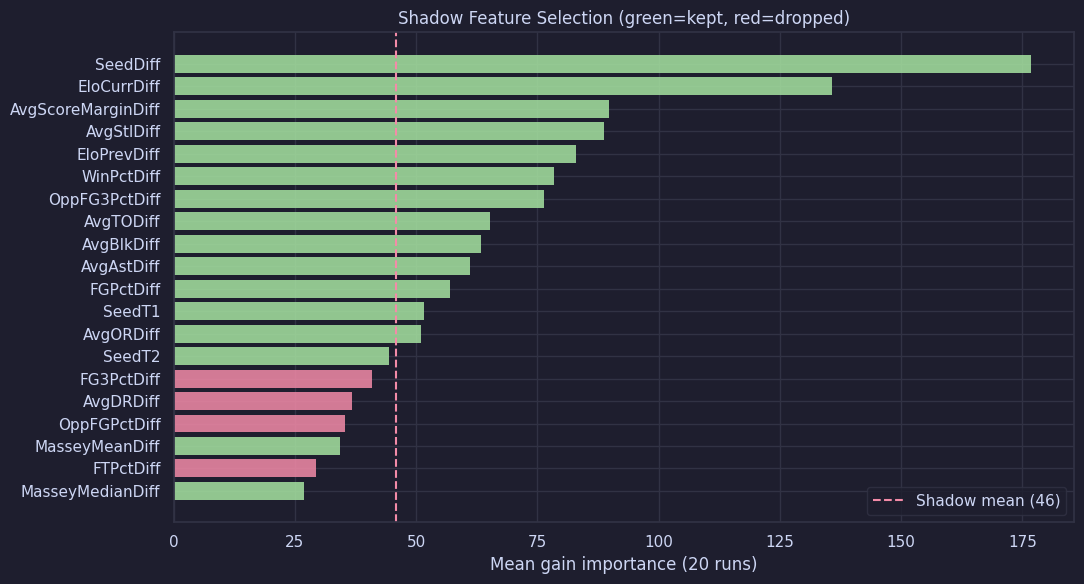

In [62]:
import json as _json
from pathlib import Path as _Path

_CACHE = _Path("cache")
_X_PATH  = _CACHE / "X.parquet"
_META_PATH = _CACHE / "meta.json"

if _X_PATH.exists() and _META_PATH.exists():
    # ── Fast path: load from cache ────────────────────────────
    X       = pd.read_parquet(_X_PATH)
    _meta   = _json.loads(_META_PATH.read_text())
    y       = pd.Series(_meta["y"],       name="y")
    seasons = pd.Series(_meta["seasons"], name="Season")
    FEATURE_COLS    = _meta["feature_cols"]
    IMPUTE_MEDIANS  = _meta["impute_medians"]
    SAMPLE_WEIGHTS  = np.array(_meta["sample_weights"])
    print(f"[cache] Loaded X{X.shape}, {len(FEATURE_COLS)} features, {len(seasons.unique())} seasons")

else:
    # ── Shadow feature selection ──────────────────────────────
    from lightgbm import LGBMClassifier as _LGBM

    # Features with structured NaN (not noise) — always keep regardless of shadow score
    FORCE_KEEP = {"MasseyMeanDiff", "MasseyMedianDiff", "SeedT1", "SeedT2"}

    N_RUNS = 20
    X_imp_full = X.fillna(IMPUTE_MEDIANS)
    orig_cols = list(X_imp_full.columns)

    importance_orig   = np.zeros(len(orig_cols))
    importance_shadow = np.zeros(len(orig_cols))

    rng = np.random.default_rng(42)
    for run in range(N_RUNS):
        shadow_cols = [f"shadow_{c}" for c in orig_cols]
        X_shadow = X_imp_full.copy()
        for col, scol in zip(orig_cols, shadow_cols):
            X_shadow[scol] = rng.permutation(X_imp_full[col].values)

        m = _LGBM(n_estimators=200, max_depth=4, learning_rate=0.05,
                   num_leaves=31, verbose=-1, random_state=run)
        m.fit(X_shadow.values, y.values)

        imp = dict(zip(orig_cols + shadow_cols, m.feature_importances_))
        for i, col in enumerate(orig_cols):
            importance_orig[i]   += imp[col]
            importance_shadow[i] += imp[f"shadow_{col}"]

    importance_orig   /= N_RUNS
    importance_shadow /= N_RUNS

    # Use mean shadow importance (not max) — less conservative, avoids single-shadow fluke
    shadow_threshold = importance_shadow.mean()
    selected = [
        col for col, imp in zip(orig_cols, importance_orig)
        if imp > shadow_threshold or col in FORCE_KEEP
    ]
    dropped  = [col for col in orig_cols if col not in selected]

    print(f"Shadow threshold (mean): {shadow_threshold:.1f}")
    print(f"KEPT    ({len(selected)}): {selected}")
    print(f"DROPPED ({len(dropped)}): {dropped}")

    X = X[selected]
    FEATURE_COLS   = selected
    IMPUTE_MEDIANS = X.median().to_dict()
    print(f"\nFeature count: {len(orig_cols)} → {len(FEATURE_COLS)}")

    # ── Save to cache ─────────────────────────────────────────
    _CACHE.mkdir(exist_ok=True)
    X.to_parquet(_X_PATH)
    _META_PATH.write_text(_json.dumps({
        "y":              y.tolist(),
        "seasons":        seasons.tolist(),
        "feature_cols":   FEATURE_COLS,
        "impute_medians": IMPUTE_MEDIANS,
        "sample_weights": SAMPLE_WEIGHTS.tolist(),
    }))
    print("[cache] Saved to cache/")

    # Visualise
    fig, ax = plt.subplots(figsize=(11, 6))
    idx = np.argsort(importance_orig)
    colors_bar = [C.green if orig_cols[i] in selected else C.red for i in idx]
    ax.barh([orig_cols[i] for i in idx], importance_orig[idx],
            color=colors_bar, alpha=0.85, edgecolor="none")
    ax.axvline(shadow_threshold, color=C.red, linestyle="--",
               label=f"Shadow mean ({shadow_threshold:.0f})")
    ax.set_xlabel("Mean gain importance (20 runs)")
    ax.set_title("Shadow Feature Selection (green=kept, red=dropped)")
    ax.legend()
    plt.tight_layout()
    plt.show()

In [63]:
import gc
# Free shadow selection intermediates
for _v in ['X_imp_full', 'importance_orig', 'importance_shadow']:
    if _v in dir(): del _v
gc.collect()
print('Memory freed after shadow selection')

Memory freed after shadow selection


## 6. Model Training with LOSO CV

**Leave-one-season-out (LOSO)** trains on all seasons except one, evaluates on the held-out season.
This matches the competition's temporal structure and avoids data leakage.

In [64]:
# XGBoost
xgb_params = {
    "n_estimators": [200, 300, 500],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9],
    "min_child_weight": [1, 3, 5],
    "reg_alpha": [0, 0.1, 1.0],
    "reg_lambda": [1.0, 2.0, 5.0],
}

xgb_model = train_or_load(
    "xgboost",
    XGBClassifier,
    X.values, y.values,
    param_dist=xgb_params,
    random_state=RANDOM_STATE,
    model_kwargs={"eval_metric": "logloss", "verbosity": 0},
    sample_weight=SAMPLE_WEIGHTS,
    n_iter=50, cv=5, scoring="neg_brier_score", n_jobs=-1,
)

print("\nXGBoost LOSO CV:")
xgb_cv, xgb_oof = leave_one_season_out_cv(
    lambda: XGBClassifier(**xgb_model.get_params()),
    X, y, seasons,
    sample_weight=SAMPLE_WEIGHTS,
    return_preds=True,
)

Best params: {'subsample': 0.7, 'reg_lambda': 1.0, 'reg_alpha': 0, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.7}

XGBoost LOSO CV:
  LOSO mean Brier: 0.1725


In [65]:
# XGBoost per-season Brier breakdown
xgb_season_df = pd.Series(xgb_cv, name='XGBoost').rename_axis('Season').to_frame()
xgb_season_df['Weight'] = [f'{0.60 ** (2025 - s):.3f}' for s in xgb_season_df.index]
xgb_season_df.loc['Mean (all)']    = [xgb_season_df['XGBoost'].mean(), '']
xgb_season_df.loc['Mean (22-25)']  = [xgb_season_df.loc[[s for s in xgb_cv if s >= 2022], 'XGBoost'].mean(), '']
print(xgb_season_df.round(4).to_string())

              XGBoost Weight
Season                      
2003           0.1588  0.000
2004           0.1764  0.000
2005           0.1727  0.000
2006           0.1698  0.000
2007           0.1680  0.000
2008           0.1347  0.000
2009           0.1752  0.000
2010           0.1754  0.000
2011           0.1822  0.001
2012           0.1616  0.001
2013           0.1938  0.002
2014           0.1822  0.004
2015           0.1535  0.006
2016           0.1855  0.010
2017           0.1605  0.017
2018           0.1975  0.028
2019           0.1574  0.047
2021           0.2029  0.130
2022           0.1937  0.216
2023           0.1871  0.360
2024           0.1643  0.600
2025           0.1413  1.000
Mean (all)     0.1725       
Mean (22-25)   0.1716       


In [66]:
# LightGBM
lgbm_params = {
    "n_estimators": [200, 300, 500],
    "max_depth": [3, 5, 7, -1],
    "learning_rate": [0.01, 0.05, 0.1],
    "num_leaves": [15, 31, 63],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9],
    "min_child_samples": [5, 10, 20],
    "reg_alpha": [0, 0.1, 1.0],
    "reg_lambda": [1.0, 2.0, 5.0],
}

lgbm_model = train_or_load(
    "lightgbm",
    LGBMClassifier,
    X.values, y.values,
    param_dist=lgbm_params,
    random_state=RANDOM_STATE,
    model_kwargs={"verbose": -1},
    sample_weight=SAMPLE_WEIGHTS,
    n_iter=50, cv=5, scoring="neg_brier_score", n_jobs=-1,
)

print("\nLightGBM LOSO CV:")
lgbm_cv, lgbm_oof = leave_one_season_out_cv(
    lambda: LGBMClassifier(**lgbm_model.get_params()),
    X, y, seasons,
    sample_weight=SAMPLE_WEIGHTS,
    return_preds=True,
)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

KeyboardInterrupt: 

In [ ]:
# CatBoost — ordered boosting, handles NaN natively, strong on small datasets
cb_params = {
    "iterations": [500, 1000, 2000],
    "depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.02, 0.05],
    "l2_leaf_reg": [1, 3, 5, 10],
    "min_data_in_leaf": [5, 10, 20],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bylevel": [0.7, 0.8, 0.9],
}

X_imputed = X.fillna(IMPUTE_MEDIANS)

cb_model = train_or_load(
    "catboost",
    CatBoostClassifier,
    X_imputed.values, y.values,
    param_dist=cb_params,
    random_state=RANDOM_STATE,
    model_kwargs={"verbose": 0, "eval_metric": "Logloss"},
    sample_weight=SAMPLE_WEIGHTS,
    n_iter=40, cv=5, scoring="neg_brier_score", n_jobs=-1,
)

print("\nCatBoost LOSO CV:")
cb_cv, cb_oof = leave_one_season_out_cv(
    lambda: CatBoostClassifier(**{k: v for k, v in cb_model.get_params().items()
                                  if k not in ("nan_value_treatment", "verbose")}, verbose=0),
    X, y, seasons,
    impute=True,
    sample_weight=SAMPLE_WEIGHTS,
    return_preds=True,
)

In [ ]:
# TabICL v2 — pretrained foundation model, no hyperparameter search
tabicl_model = train_or_load("tabicl", TabICLClassifier, X_imputed.values, y.values,
                              param_dist=None, model_kwargs={"n_estimators": 16})

print("\nTabICL LOSO CV (with imputation):")
tabicl_cv, tabicl_oof = leave_one_season_out_cv(
    lambda: TabICLClassifier(n_estimators=16, random_state=RANDOM_STATE),
    X, y, seasons,
    impute=True,
    return_preds=True,
)


In [ ]:
# CV summary table
cv_results = {
    "XGBoost":  xgb_cv,
    "LightGBM": lgbm_cv,
    "CatBoost": cb_cv,
    "TabICL":   tabicl_cv,
}

cv_df = pd.DataFrame(cv_results).sort_index()
cv_df.loc['Mean (all)']   = cv_df.mean()
recent = [s for s in cv_results['XGBoost'] if s >= 2022]
cv_df.loc['Mean (22-25)'] = cv_df.loc[recent].mean()
print(cv_df.round(4).to_string())


In [ ]:
plot_brier_by_season(cv_results, C.cycle)
plt.show()

## 7. Ensemble

In [ ]:
from scipy.optimize import minimize

# Optimize ensemble weights directly on OOF predictions (recent seasons only)
recent_mask = np.array([s >= 2022 for s in seasons])
oofs = np.column_stack([xgb_oof, lgbm_oof, cb_oof, tabicl_oof])
y_arr = y.values

def neg_brier(w):
    w = np.abs(w) / np.abs(w).sum()  # normalise, no negatives
    preds = oofs[recent_mask] @ w
    return np.mean((preds - y_arr[recent_mask]) ** 2)

res = minimize(neg_brier, x0=[0.25, 0.25, 0.25, 0.25],
               method='Nelder-Mead', options={'xatol': 1e-6, 'fatol': 1e-6, 'maxiter': 10000})
w_opt = np.abs(res.x) / np.abs(res.x).sum()
model_names = ['XGBoost', 'LightGBM', 'CatBoost', 'TabICL']
weights = dict(zip(model_names, w_opt))

# Also store per-model 22-25 Brier for reference
mean_briers = {
    name: np.mean([v for s, v in cv.items() if s >= 2022])
    for name, cv in cv_results.items()
}

print('Optimised ensemble weights (22-25 OOF):')
for name, b in sorted(mean_briers.items(), key=lambda x: x[1]):
    print(f'  {name:10s}  Brier={b:.4f}  weight={weights[name]:.3f}')


Model performance (Mean 22-25) and ensemble weights:
  TabICL      Brier=0.1661  weight=0.255
  CatBoost    Brier=0.1692  weight=0.250
  LightGBM    Brier=0.1707  weight=0.248
  XGBoost     Brier=0.1716  weight=0.247


In [ ]:
# Ensemble LOSO — combine stored OOF predictions (no retraining)
oof_ensemble = (
    weights['XGBoost']  * xgb_oof +
    weights['LightGBM'] * lgbm_oof +
    weights['CatBoost'] * cb_oof +
    weights['TabICL']   * tabicl_oof
)

ensemble_cv = {}
for season in sorted(seasons.unique()):
    mask = (seasons == season).values
    ensemble_cv[season] = brier_score(y[mask].values, oof_ensemble[mask])

ens_all  = np.mean(list(ensemble_cv.values()))
ens_2225 = np.mean([v for s, v in ensemble_cv.items() if s >= 2022])
mean_briers['Ensemble'] = ens_2225
print(f'Ensemble mean Brier (all):   {ens_all:.4f}')
print(f'Ensemble mean Brier (22-25): {ens_2225:.4f}')
print(pd.Series(ensemble_cv, name='Brier').sort_index().round(4))


Ensemble mean Brier (all):   0.1685
Ensemble mean Brier (22-25): 0.1667
2003    0.1537
2004    0.1718
2005    0.1683
2006    0.1688
2007    0.1650
2008    0.1310
2009    0.1681
2010    0.1734
2011    0.1792
2012    0.1588
2013    0.1898
2014    0.1797
2015    0.1489
2016    0.1822
2017    0.1587
2018    0.1929
2019    0.1537
2021    0.1961
2022    0.1864
2023    0.1874
2024    0.1599
2025    0.1332
Name: Brier, dtype: float64


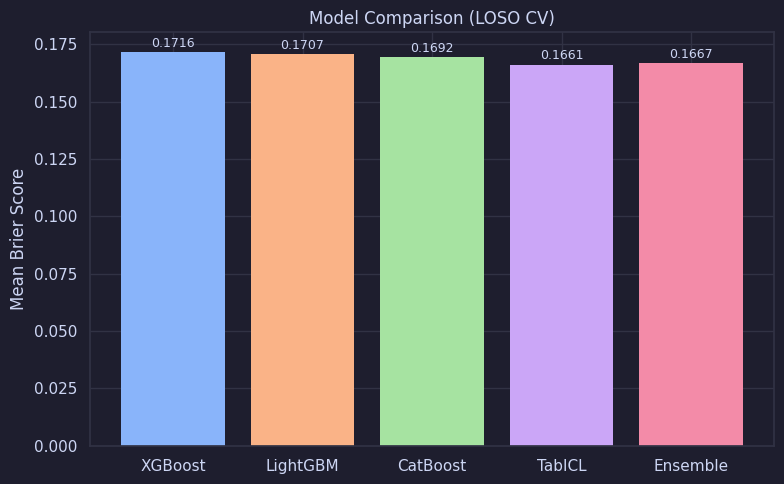

In [ ]:
plot_model_comparison(mean_briers, C.cycle)
plt.show()

## 8. Submission Generation

In [ ]:
models = {
    "XGBoost":  xgb_model,
    "LightGBM": lgbm_model,
    "CatBoost": cb_model,
    "TabICL":   tabicl_model,
}

In [ ]:
# Stage 1: seasons 2022–2025
sub1 = generate_submission(
    data["sample_sub"], models, weights,
    elo_prev, elo_curr, seed_map, stats_df, massey_df,
    feature_cols=FEATURE_COLS,
    impute_medians=IMPUTE_MEDIANS,
)
sub1.to_csv("submission_stage1.csv", index=False)
print(f"Stage 1: {sub1.shape[0]:,} rows")
print(f"Range : [{sub1['Pred'].min():.4f}, {sub1['Pred'].max():.4f}]")
print(f"Mean  : {sub1['Pred'].mean():.4f}  Std: {sub1['Pred'].std():.4f}")
sub1.head()

Building features...
  Feature matrix: (519144, 16)
  XGBoost: mean=0.5294, std=0.1944
  LightGBM: mean=0.5188, std=0.2219
  CatBoost: mean=0.5055, std=0.2390


In [ ]:
# Stage 2: season 2026
sub2 = generate_submission(
    data["sample_sub2"], models, weights,
    elo_prev, elo_curr, seed_map, stats_df, massey_df,
    feature_cols=FEATURE_COLS,
    impute_medians=IMPUTE_MEDIANS,
)
sub2.to_csv("submission_stage2.csv", index=False)
print(f"Stage 2: {sub2.shape[0]:,} rows")
print(f"Range : [{sub2['Pred'].min():.4f}, {sub2['Pred'].max():.4f}]")
print(f"Mean  : {sub2['Pred'].mean():.4f}  Std: {sub2['Pred'].std():.4f}")
sub2.head()

## 9. Validation Visualizations

In [ ]:
plot_prediction_distribution(sub1["Pred"], color=C.blue)
plt.title("Stage 1: Prediction Distribution")
plt.show()

In [ ]:
# Feature importance: XGBoost and LightGBM
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_feature_importance(xgb_model,  FEATURE_COLS, top_n=15, color=C.blue,  ax=axes[0])
plot_feature_importance(lgbm_model, FEATURE_COLS, top_n=15, color=C.peach, ax=axes[1])
axes[0].set_title("XGBoost Feature Importance")
axes[1].set_title("LightGBM Feature Importance")
plt.tight_layout()
plt.show()

In [ ]:
# Calibration curve on LOSO held-out predictions (proper out-of-fold)
oof_preds = np.zeros(len(y))
for season in sorted(seasons.unique()):
    train_mask = seasons != season
    test_mask  = seasons == season
    m = XGBClassifier(**xgb_model.get_params())
    m.fit(X[train_mask].values, y[train_mask].values)
    oof_preds[test_mask] = m.predict_proba(X[test_mask].values)[:, 1]

plot_calibration_curve(y.values, oof_preds, color=C.blue)
plt.title("XGBoost Calibration (LOSO out-of-fold)")
plt.show()

In [ ]:
# Men's vs Women's prediction distributions (Stage 1)
ids_parsed = sub1["ID"].str.split("_", expand=True).astype(int)
is_mens = ids_parsed[1] < 2000

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (mask, title, color) in zip(axes, [
    (is_mens,  "Men's",   C.blue),
    (~is_mens, "Women's", C.pink),
]):
    preds_sub = sub1.loc[mask.values, "Pred"]
    ax.hist(preds_sub, bins=50, color=color, edgecolor="none", alpha=0.85)
    ax.axvline(0.5, color=C.red, linestyle="--", alpha=0.6)
    ax.set_xlabel("P(Team1 wins)")
    ax.set_title(f"{title} ({len(preds_sub):,} matchups)")
axes[0].set_ylabel("Count")
plt.suptitle("Stage 1: Prediction Distribution by Gender")
plt.tight_layout()
plt.show()

In [ ]:
# Sanity check: seed-based predictions for 2024
check_season = 2024
check_sub = sub1[sub1["ID"].str.startswith(f"{check_season}_")].copy()
check_ids = check_sub["ID"].str.split("_", expand=True).astype(int)
check_ids.columns = ["Season", "T1", "T2"]
check_ids["Seed1"] = check_ids.apply(lambda r: seed_map.get((r["Season"], r["T1"])), axis=1)
check_ids["Seed2"] = check_ids.apply(lambda r: seed_map.get((r["Season"], r["T2"])), axis=1)
check_ids["Pred"]  = check_sub["Pred"].values

seeded = check_ids.dropna(subset=["Seed1", "Seed2"])
print(f"Seeded matchups in {check_season}: {len(seeded):,}")

vs1_16 = seeded[(seeded["Seed1"] == 1) & (seeded["Seed2"] == 16)]
print(f"\n1 vs 16 seed predictions (expect >0.5 for Team1):")
print(vs1_16[["T1", "T2", "Seed1", "Seed2", "Pred"]].round(3).to_string(index=False))

vs8_9  = seeded[(seeded["Seed1"] == 8) & (seeded["Seed2"] == 9)]
print(f"\n8 vs 9 seed predictions (expect ~0.5):")
print(vs8_9[["T1", "T2", "Seed1", "Seed2", "Pred"]].round(3).to_string(index=False))